## NEP_RDF

### XYZ文件预处理

In [1]:
# input_file = "./split_xyz_files/split_460.xyz"
# output_file = "./substitute_xyz_files/split_460.xyz"

# with open(input_file, 'r') as file:
#     lines = file.readlines()

# # 初始化变量
# num_atoms = 867  # 每帧的原子数
# num_frames = 1000  # 总帧数
# frame_lines = num_atoms + 2

# # 处理每一帧
# for i in range(num_frames):
#     start = i * frame_lines
#     end = start + frame_lines
#     frame = lines[start:end]
    
#     # 处理每一行原子信息
#     for j in range(2, len(frame)):
#         atom_info = frame[j].split()
#         element = atom_info[0]
#         z_coord = float(atom_info[3])
        
#         # 如果是Te原子且z坐标小于40，替换成Sb原子
#         if element == 'Te' and z_coord < 40:
#             frame[j] = frame[j].replace('Te', 'Sb', 1)
    
#     # 替换原来的帧信息
#     lines[start:end] = frame

# # 将结果写入新文件
# with open(output_file, 'w') as file:
#     file.writelines(lines)


### XYZ文件分析

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*OVITO.*PyPI')

from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from ovito.io import import_file, export_file
from ovito.modifiers import BondAnalysisModifier, CoordinationAnalysisModifier, CreateBondsModifier, TimeAveragingModifier

plt.style.use(['science','ieee','no-latex','bright'])

colors = sns.color_palette("rocket")[::-1]

temp = 480
filename = f"./substitute_xyz_files/split_{temp}.xyz"
pipeline = import_file(filename)

for t in pipeline.compute().particles.particle_types.types:
    print("Type %i: %s" % (t.id, t.name))
print("Number of frames: ", pipeline.source.num_frames)

Type 1: Ge
Type 2: Sb
Type 3: Te
Number of frames:  1000


In [3]:
create_bonds = CreateBondsModifier(mode=CreateBondsModifier.Mode.Pairwise)
create_bonds.set_pairwise_cutoff(1, 2, 4)
create_bonds.set_pairwise_cutoff(1, 3, 4)
pipeline.modifiers.append(create_bonds)

pipeline.modifiers.append(BondAnalysisModifier(partition=BondAnalysisModifier.Partition.ByBondType, bins=1000))
pipeline.modifiers.append(CoordinationAnalysisModifier(cutoff=4, number_of_bins=1000, partial=True)) # , partial=False
rdf, bad, bld = [], [], []
for i in range(pipeline.source.num_frames):
    data = pipeline.compute(i)
    rdf.append(data.tables['coordination-rdf'].xy())
    bad.append(data.tables['bond-angle-distr'].xy())
    bld.append(data.tables['bond-length-distr'].xy())
    
rdf = np.mean(rdf, axis=0)
bad = np.mean(bad, axis=0)
bld = np.mean(bld, axis=0)

rdf.shape, bad.shape, bld.shape

((1000, 7), (1000, 2), (1000, 2))

In [4]:
pipeline_12 = import_file(filename)

create_bonds = CreateBondsModifier(mode=CreateBondsModifier.Mode.Pairwise)
create_bonds.set_pairwise_cutoff(1, 2, 4)
pipeline_12.modifiers.append(create_bonds)

pipeline_12.modifiers.append(BondAnalysisModifier(partition=BondAnalysisModifier.Partition.ByBondType, bins=1000))
pipeline_12.modifiers.append(CoordinationAnalysisModifier(cutoff=4, number_of_bins=1000, partial=True)) # , partial=False
rdf_12, bad_12, bld_12 = [], [], []
for i in range(pipeline_12.source.num_frames):
    data = pipeline_12.compute(i)
    rdf_12.append(data.tables['coordination-rdf'].xy())
    bad_12.append(data.tables['bond-angle-distr'].xy())
    bld_12.append(data.tables['bond-length-distr'].xy())
    
rdf_12 = np.mean(rdf_12, axis=0)
bad_12 = np.mean(bad_12, axis=0)
bld_12 = np.mean(bld_12, axis=0)

rdf_12.shape, bad_12.shape, bld_12.shape

((1000, 7), (1000, 2), (1000, 2))

In [5]:
pipeline_13 = import_file(filename)

create_bonds = CreateBondsModifier(mode=CreateBondsModifier.Mode.Pairwise)
create_bonds.set_pairwise_cutoff(1, 3, 4)
pipeline_13.modifiers.append(create_bonds)

pipeline_13.modifiers.append(BondAnalysisModifier(partition=BondAnalysisModifier.Partition.ByBondType, bins=1000))
pipeline_13.modifiers.append(CoordinationAnalysisModifier(cutoff=4, number_of_bins=1000, partial=True)) # , partial=False
rdf_13, bad_13, bld_13 = [], [], []
for i in range(pipeline_13.source.num_frames):
    data = pipeline_13.compute(i)
    rdf_13.append(data.tables['coordination-rdf'].xy())
    bad_13.append(data.tables['bond-angle-distr'].xy())
    bld_13.append(data.tables['bond-length-distr'].xy())
    
rdf_13 = np.mean(rdf_13, axis=0)
bad_13 = np.mean(bad_13, axis=0)
bld_13 = np.mean(bld_13, axis=0)

rdf_13.shape, bad_13.shape, bld_13.shape

((1000, 7), (1000, 2), (1000, 2))

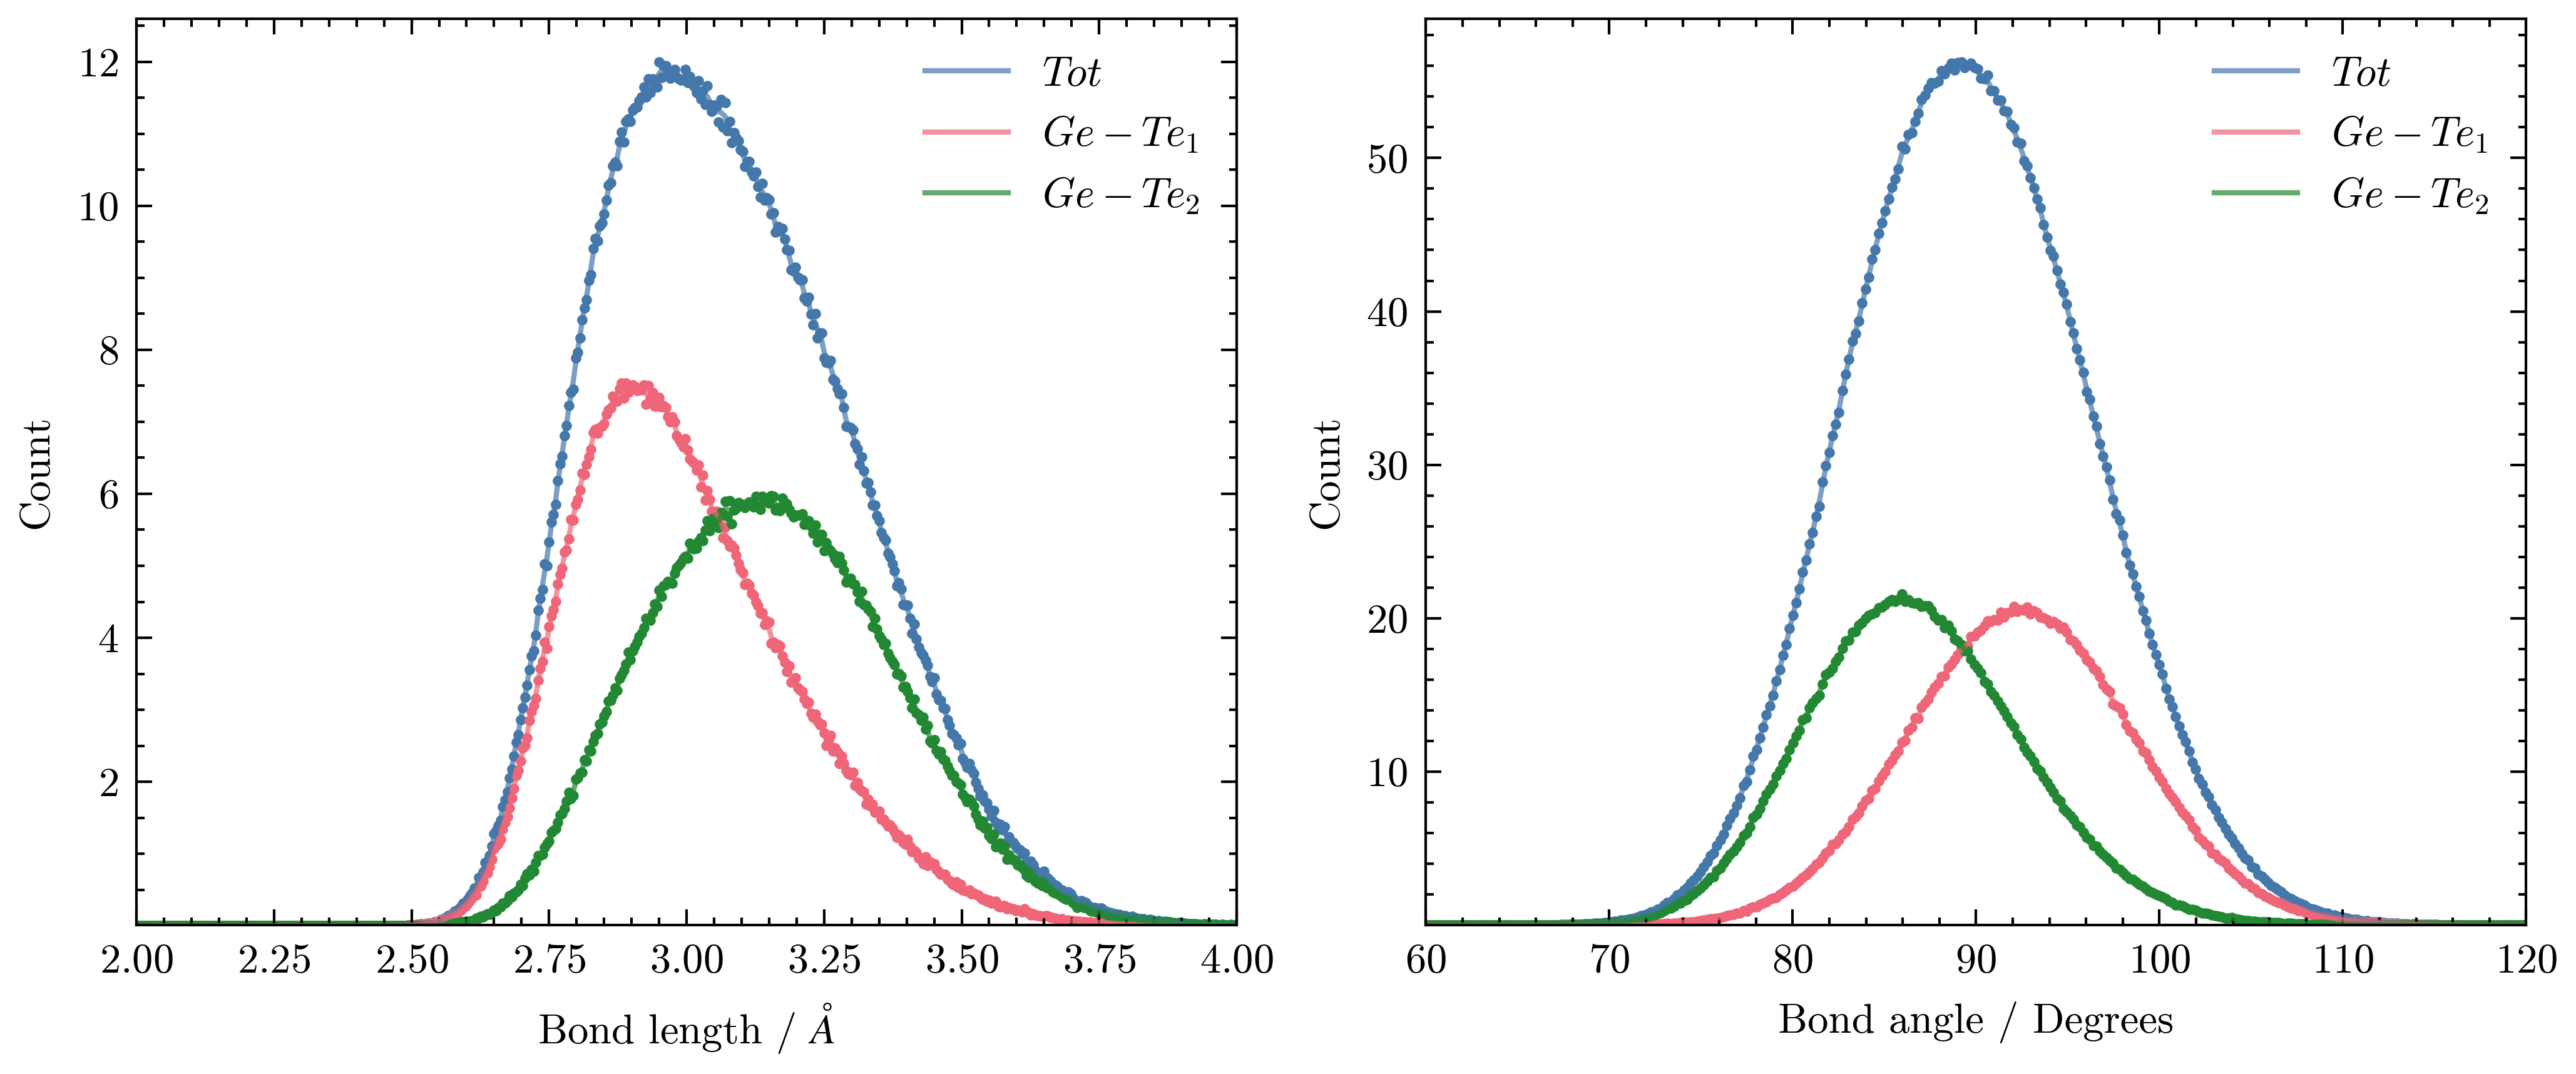

In [6]:
plt.figure(figsize=(7,3))

plt.subplot(1, 2, 1)
plt.scatter(bld[:,0], bld[:,1], s=1)
plt.plot(bld[:,0], gaussian_filter1d(bld[:,1], sigma=1), alpha=0.7, label="$Tot$")
plt.scatter(bld_12[:,0], bld_12[:,1], s=1)
plt.plot(bld_12[:,0], gaussian_filter1d(bld_12[:,1], sigma=1), alpha=0.7, label="$Ge-Te_{1}$")
plt.scatter(bld_13[:,0], bld_13[:,1], s=1)
plt.plot(bld_13[:,0], gaussian_filter1d(bld_13[:,1], sigma=1), alpha=0.7, label="$Ge-Te_{2}$")
plt.xlabel('Bond length / $Å$')
plt.ylabel('Count')
plt.xlim(2.0, 4.0)
plt.ylim(0.01, None)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(bad[:,0], bad[:,1], s=1)
plt.plot(bad[:,0], gaussian_filter1d(bad[:,1], sigma=1), alpha=0.7, label="$Tot$")
plt.scatter(bad_12[:,0], bad_12[:,1], s=1)
plt.plot(bad_12[:,0], gaussian_filter1d(bad_12[:,1], sigma=1), alpha=0.7, label="$Ge-Te_{1}$")
plt.scatter(bad_13[:,0], bad_13[:,1], s=1)
plt.plot(bad_13[:,0], gaussian_filter1d(bad_13[:,1], sigma=1), alpha=0.7, label="$Ge-Te_{2}$")   
plt.xlabel('Bond angle / Degrees')
plt.ylabel('Count')
plt.xlim(60, 120)
plt.ylim(0.01, None)
plt.legend()

plt.tight_layout()
plt.savefig(f'rdf_bad_{temp}K.png', bbox_inches='tight')

### 非晶XYZ文件分析

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science','ieee','no-latex', 'bright'])

data = pd.read_csv('rdf.out', delim_whitespace=True, comment='#', header=None, 
                   names=['radius', 'total', 'Ge-Ge', 'Te-Te', 'Ge-Te'])

radius = data['radius']
total = data['total']
type_0_0 = data['Ge-Ge']
type_1_1 = data['Te-Te']
type_0_1 = data['Ge-Te']

plt.figure()
plt.plot(radius, total, label='Total')
# plt.plot(radius, type_0_0, label='Ge-Ge')
# plt.plot(radius, type_1_1, label='Te-Te')
# plt.plot(radius, type_0_1, label='Ge-Te')

plt.xlabel('Radius')
plt.ylabel('RDF Value')
plt.xlim(0, 8)
plt.ylim(0, None)
plt.legend()

plt.show()